# Test GAN 

In [1]:
import os 
import sys 
import numpy as np 
import torch 
import random

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from src.dataset.custom_dataset import GenDataset, DiscDataset
from src.model.graph_model import NEGATGenerator, DiffPoolDiscriminator
from src.training.trainer import train_GAN

from utils.gen_utils import load_config, get_device, dataset_splitter, generate_markdown_report_GAN
from utils.ppnet_utils import initialize_network
from utils.load_data_utils import load_sampled_input_data

### Initialise the configuration and data for G and D 

In [2]:
seed = 2
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

yaml_config= load_config('config_gan.yaml')

device = get_device(yaml_config['device'])

net = initialize_network(net_name=yaml_config['data']['net_name'],
                        #  net_name=yaml_config['data']['net_name'], 
                         load_std=yaml_config['data']['load_std']) 


Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



In [ ]:
########### data for generator 
sampled_input_data_G = load_sampled_input_data(sc_type=yaml_config['data']['gen_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])

# sparsity of the node and edge features 
node_feat_sparsity = np.count_nonzero(sampled_input_data_G['node_mask']) / sampled_input_data_G['node_mask'].numpy().size
pflow_edge_sparsity = np.count_nonzero(sampled_input_data_G['edge_mask'][:,:,0]) / sampled_input_data_G['edge_mask'][:,:,0].numpy().size

print(f"Sparsity of PV measurements at buses = {node_feat_sparsity:.1f}%")
print(f"Sparsity of P+ measurements at branches = {pflow_edge_sparsity:.1f}")

########### data for discriminator 
sampled_input_data_D = load_sampled_input_data(sc_type=yaml_config['data']['dis_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])

Selecting all the MV/LV transformers in the network 



### Make dataset and dataloader

In [ ]:
dataset_G = GenDataset(model_name=yaml_config['model_G']['name'], 
                       sampled_input_data=sampled_input_data_G)

(train_loader_G, val_loader_G, test_loader_G), _ = dataset_splitter(dataset_G, 
                                                                    batch_size=yaml_config['loader']['batch_size'])

dataset_D = DiscDataset(sampled_input_data=sampled_input_data_D)

(train_loader_D, val_loader_D, test_loader_D), _ = dataset_splitter(dataset_D,
                                                                    batch_size=yaml_config['loader']['batch_size'])


Dataset for NEGATGenerator selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



### Instantiate the model, optimizer, schedular 

In [ ]:
# instantiate model, optimizer and schedular for Generator 
model_G = NEGATGenerator(node_input_features=dataset_G[0][0].x.shape[-1], 
                    list_node_hidden_features=yaml_config['model_G']['list_node_hidden_features'], # [128,64], 
                    node_out_features=yaml_config['model_G']['node_out_features'], # 64, 
                    k_hop_node=yaml_config['model_G']['k_hop_node'], #1, 
                    edge_input_features=dataset_G[0][1].x.shape[-1], 
                    list_edge_hidden_features=yaml_config['model_G']['list_edge_hidden_features'], #[128,64], 
                    edge_output_features=yaml_config['model_G']['edge_out_features'], #64, 
                    k_hop_edge=yaml_config['model_G']['k_hop_edge'], #1, 
                    gat_out_features=yaml_config['model_G']['gat_out_features'], #32, 
                    gat_head=yaml_config['model_G']['gat_head'], #2, 
                    device=device)

optimizer_G = torch.optim.Adam(model_G.parameters(), 
                            lr=yaml_config['training_G']['lr'], 
                            weight_decay=yaml_config['training_G']['weight_decay'])

schedular_G = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_G, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_G']['schedular_min_lr'])

total_params_G = sum(p.numel() for p in model_G.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_G}: {total_params_G}')

# instantiate model, optimizer and schedular for Discriminator 
model_D = DiffPoolDiscriminator(in_channel=dataset_D[0].x.shape[-1], 
                            hidden_channel=yaml_config['model_D']['hidden_channel'], 
                            out_channel=yaml_config['model_D']['out_channel'], 
                            num_nodes=len(net.bus.index))

total_params_D = sum(p.numel() for p in model_D.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_D}: {total_params_D}')

optimizer_D = torch.optim.Adam(model_D.parameters(), 
                            lr=yaml_config['training_D']['lr'], 
                            weight_decay=yaml_config['training_D']['weight_decay'])

schedular_D = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_D, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_D']['schedular_min_lr'])


Total number of parameters of model NEGATGenerator(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=1, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 7363
Total number of parameters of model DiffPoolDiscriminator(): 7243


### Train the GAN 

In [ ]:
all_losses = train_GAN(model_G=model_G, 
                        model_D=model_D, 
                        all_loader_G= [train_loader_G, val_loader_G, test_loader_G], 
                        all_loader_D= [train_loader_D, val_loader_D, test_loader_D],  
                        optimizer_G=optimizer_G, 
                        optimizer_D=optimizer_D, 
                        schedular_G=schedular_G, 
                        schedular_D=schedular_D, 
                        num_epoch=yaml_config['training_GAN']['num_epoch'], 
                        disc_iter=yaml_config['training_GAN']['disc_iter'], 
                        gen_iter=yaml_config['training_GAN']['gen_iter'],
                        feature_matching=yaml_config['training_GAN']['feature_matching'],   
                        device=device)  

At epoch: 0
training: D = 5.044e+01, Acc = 0.17, G = 1.101e+01
validation: D = 8.162e+00, Acc = 0.05, G = 5.686e-01, lr_D = 1.0e-06, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 5
training: D = 5.185e+01, Acc = 0.01, G = 6.957e-02
validation: D = 7.187e+00, Acc = 0.01, G = 6.619e-02, lr_D = 1.0e-06, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 10
training: D = 5.407e+01, Acc = 0.01, G = 5.143e-02
validation: D = 6.235e+00, Acc = 0.01, G = 4.624e-02, lr_D = 1.0e-06, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 15
training: D = 5.712e+01, Acc = 0.01, G = 4.932e-02
validation: D = 5.403e+00, Acc = 0.00, G = 4.931e-02, lr_D = 1.0e-06, lr_G 1.0e-04
------------------------------------------------------------------------------
At epoch: 20
training: D = 6.400e+01, Acc = 0.03, G = 7.439e-02
validation: D = 5.172e+00, Acc = 0

### Results 

Saved in `results/GAN_results/{current_time}`

Forward pass calculated!
Inverse scale done!
Mean and variances calculated!
Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



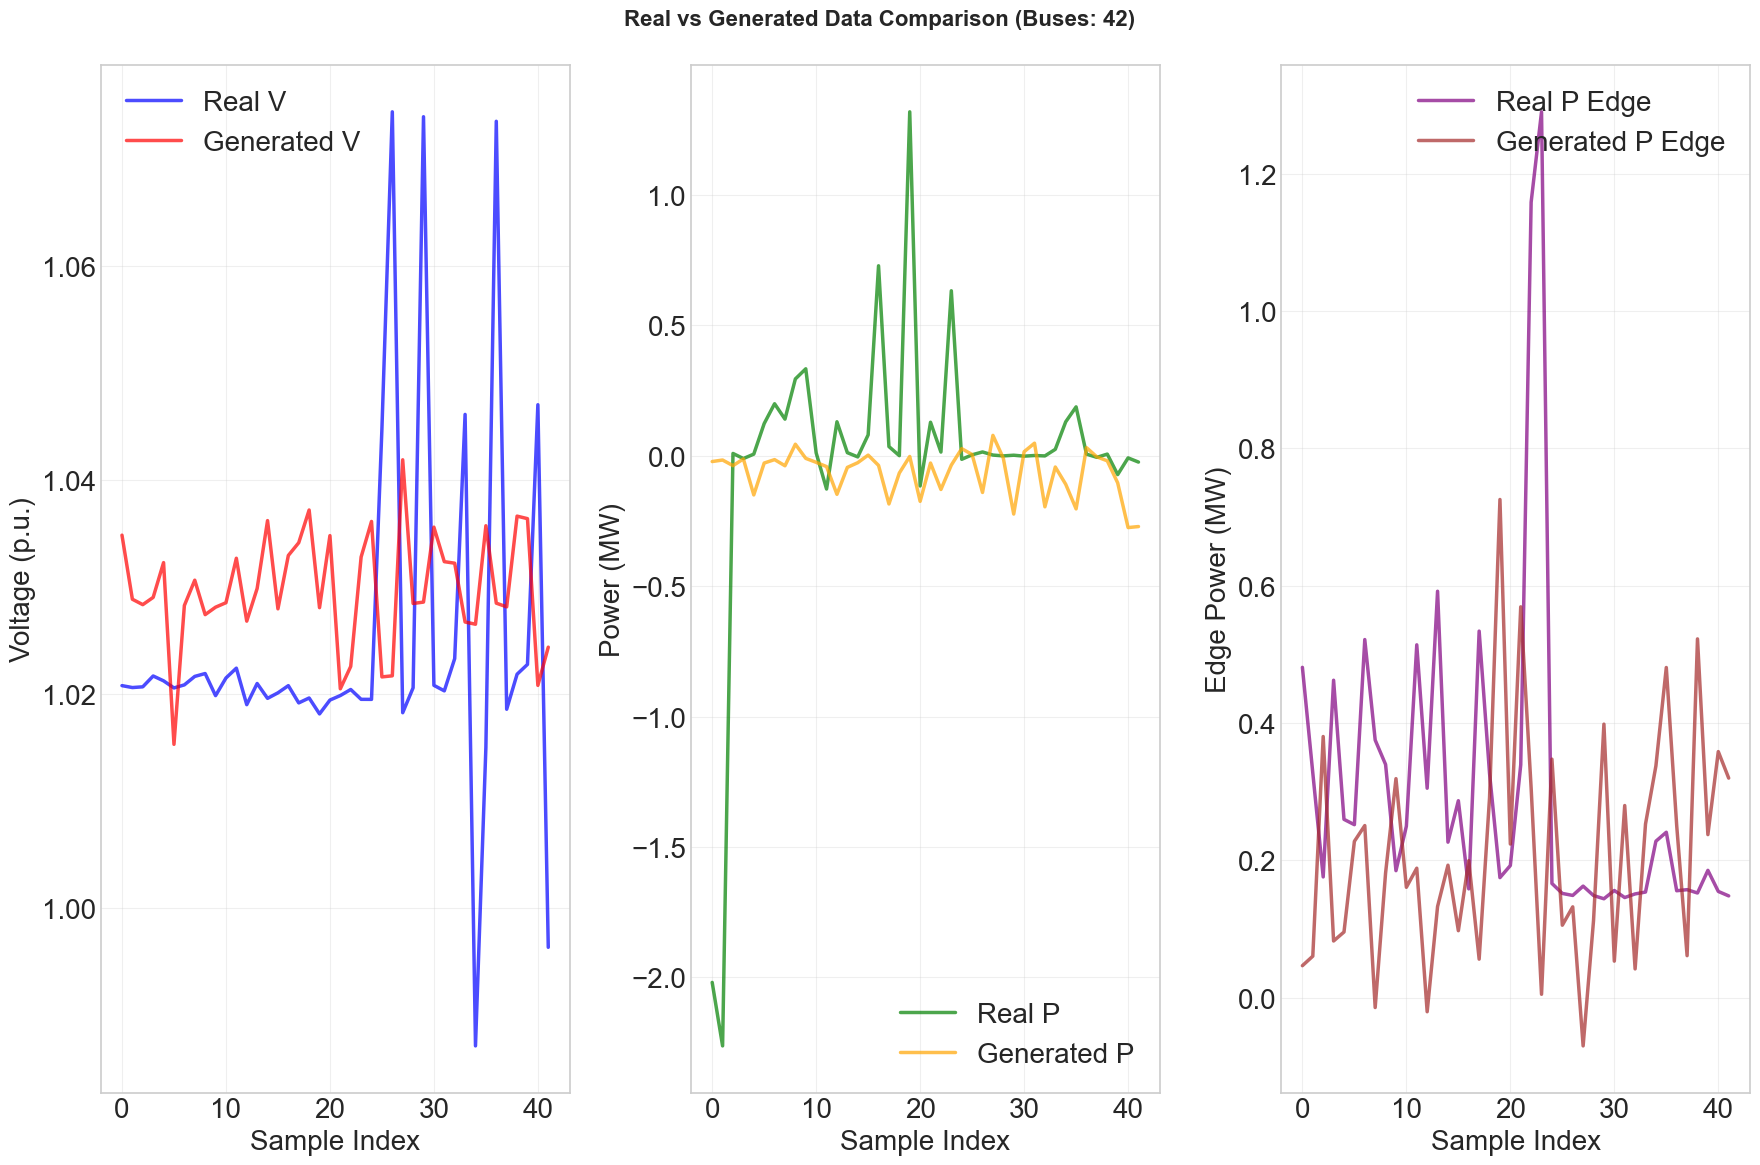

Plotted real vs. generated line-bar plots!
Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 

Power Flow Converged!
KDE plots failed!: QuadMesh.set() got an unexpected keyword argument 'fontsize'
📄 Training report saved to: /Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/results/GAN_only/20250913_165254/training_report.md


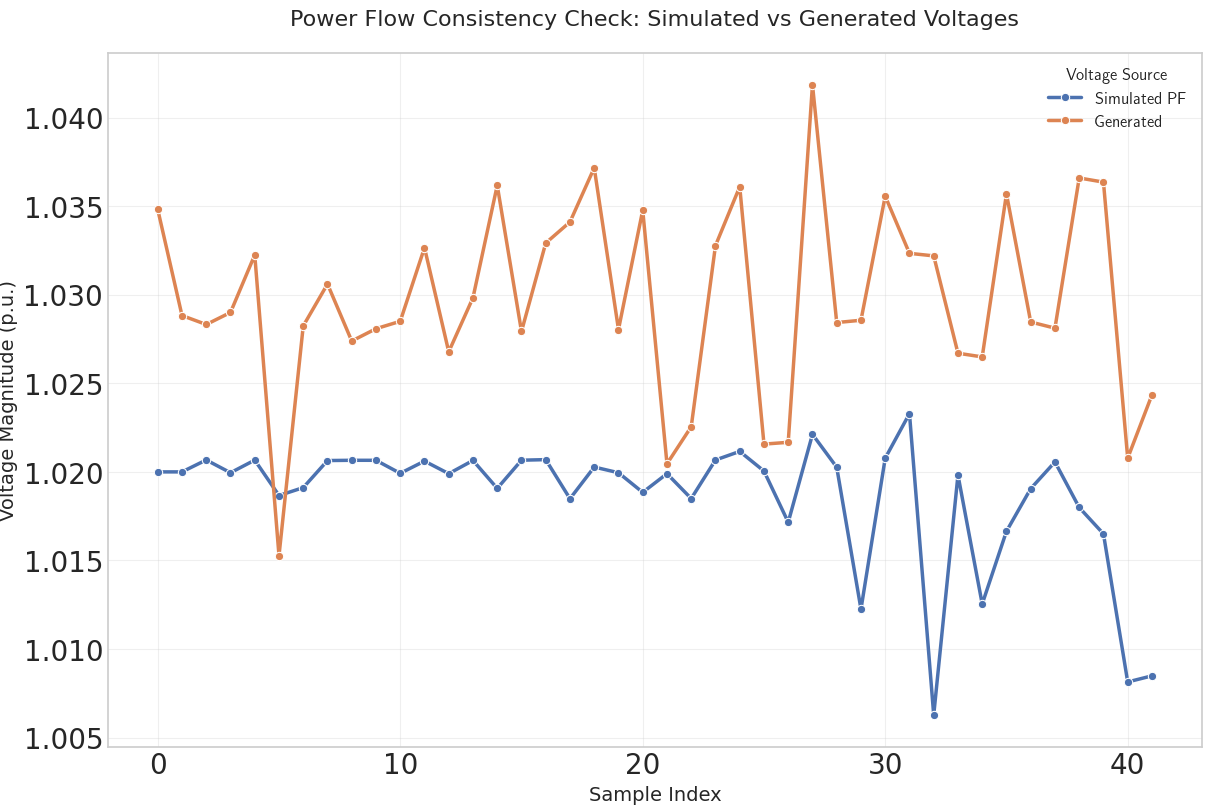

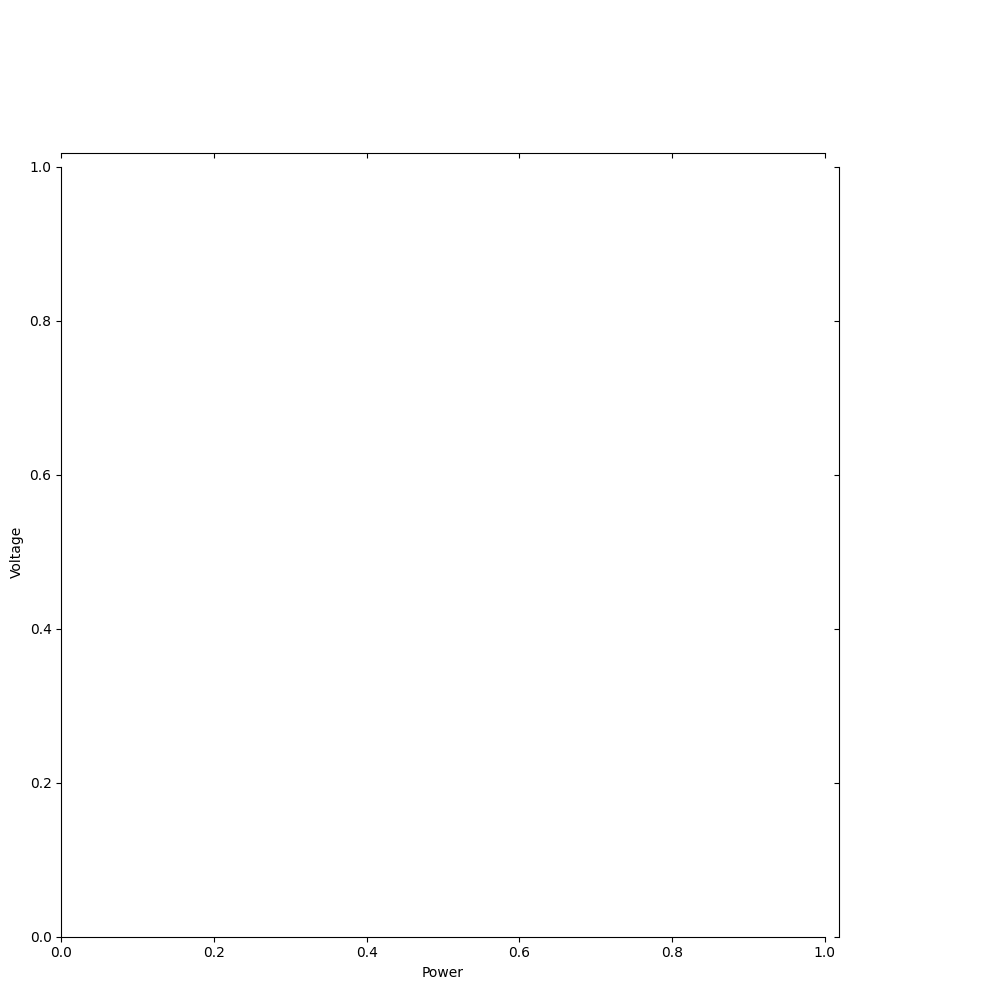

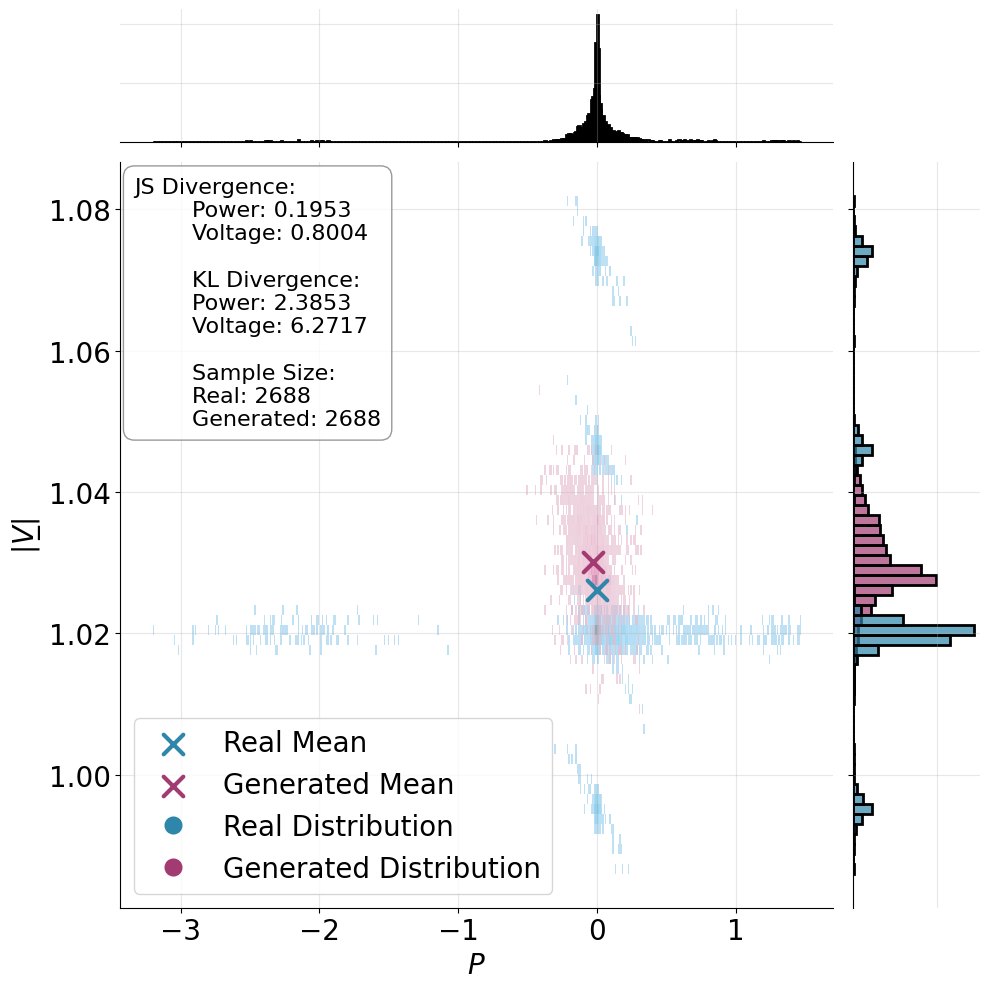

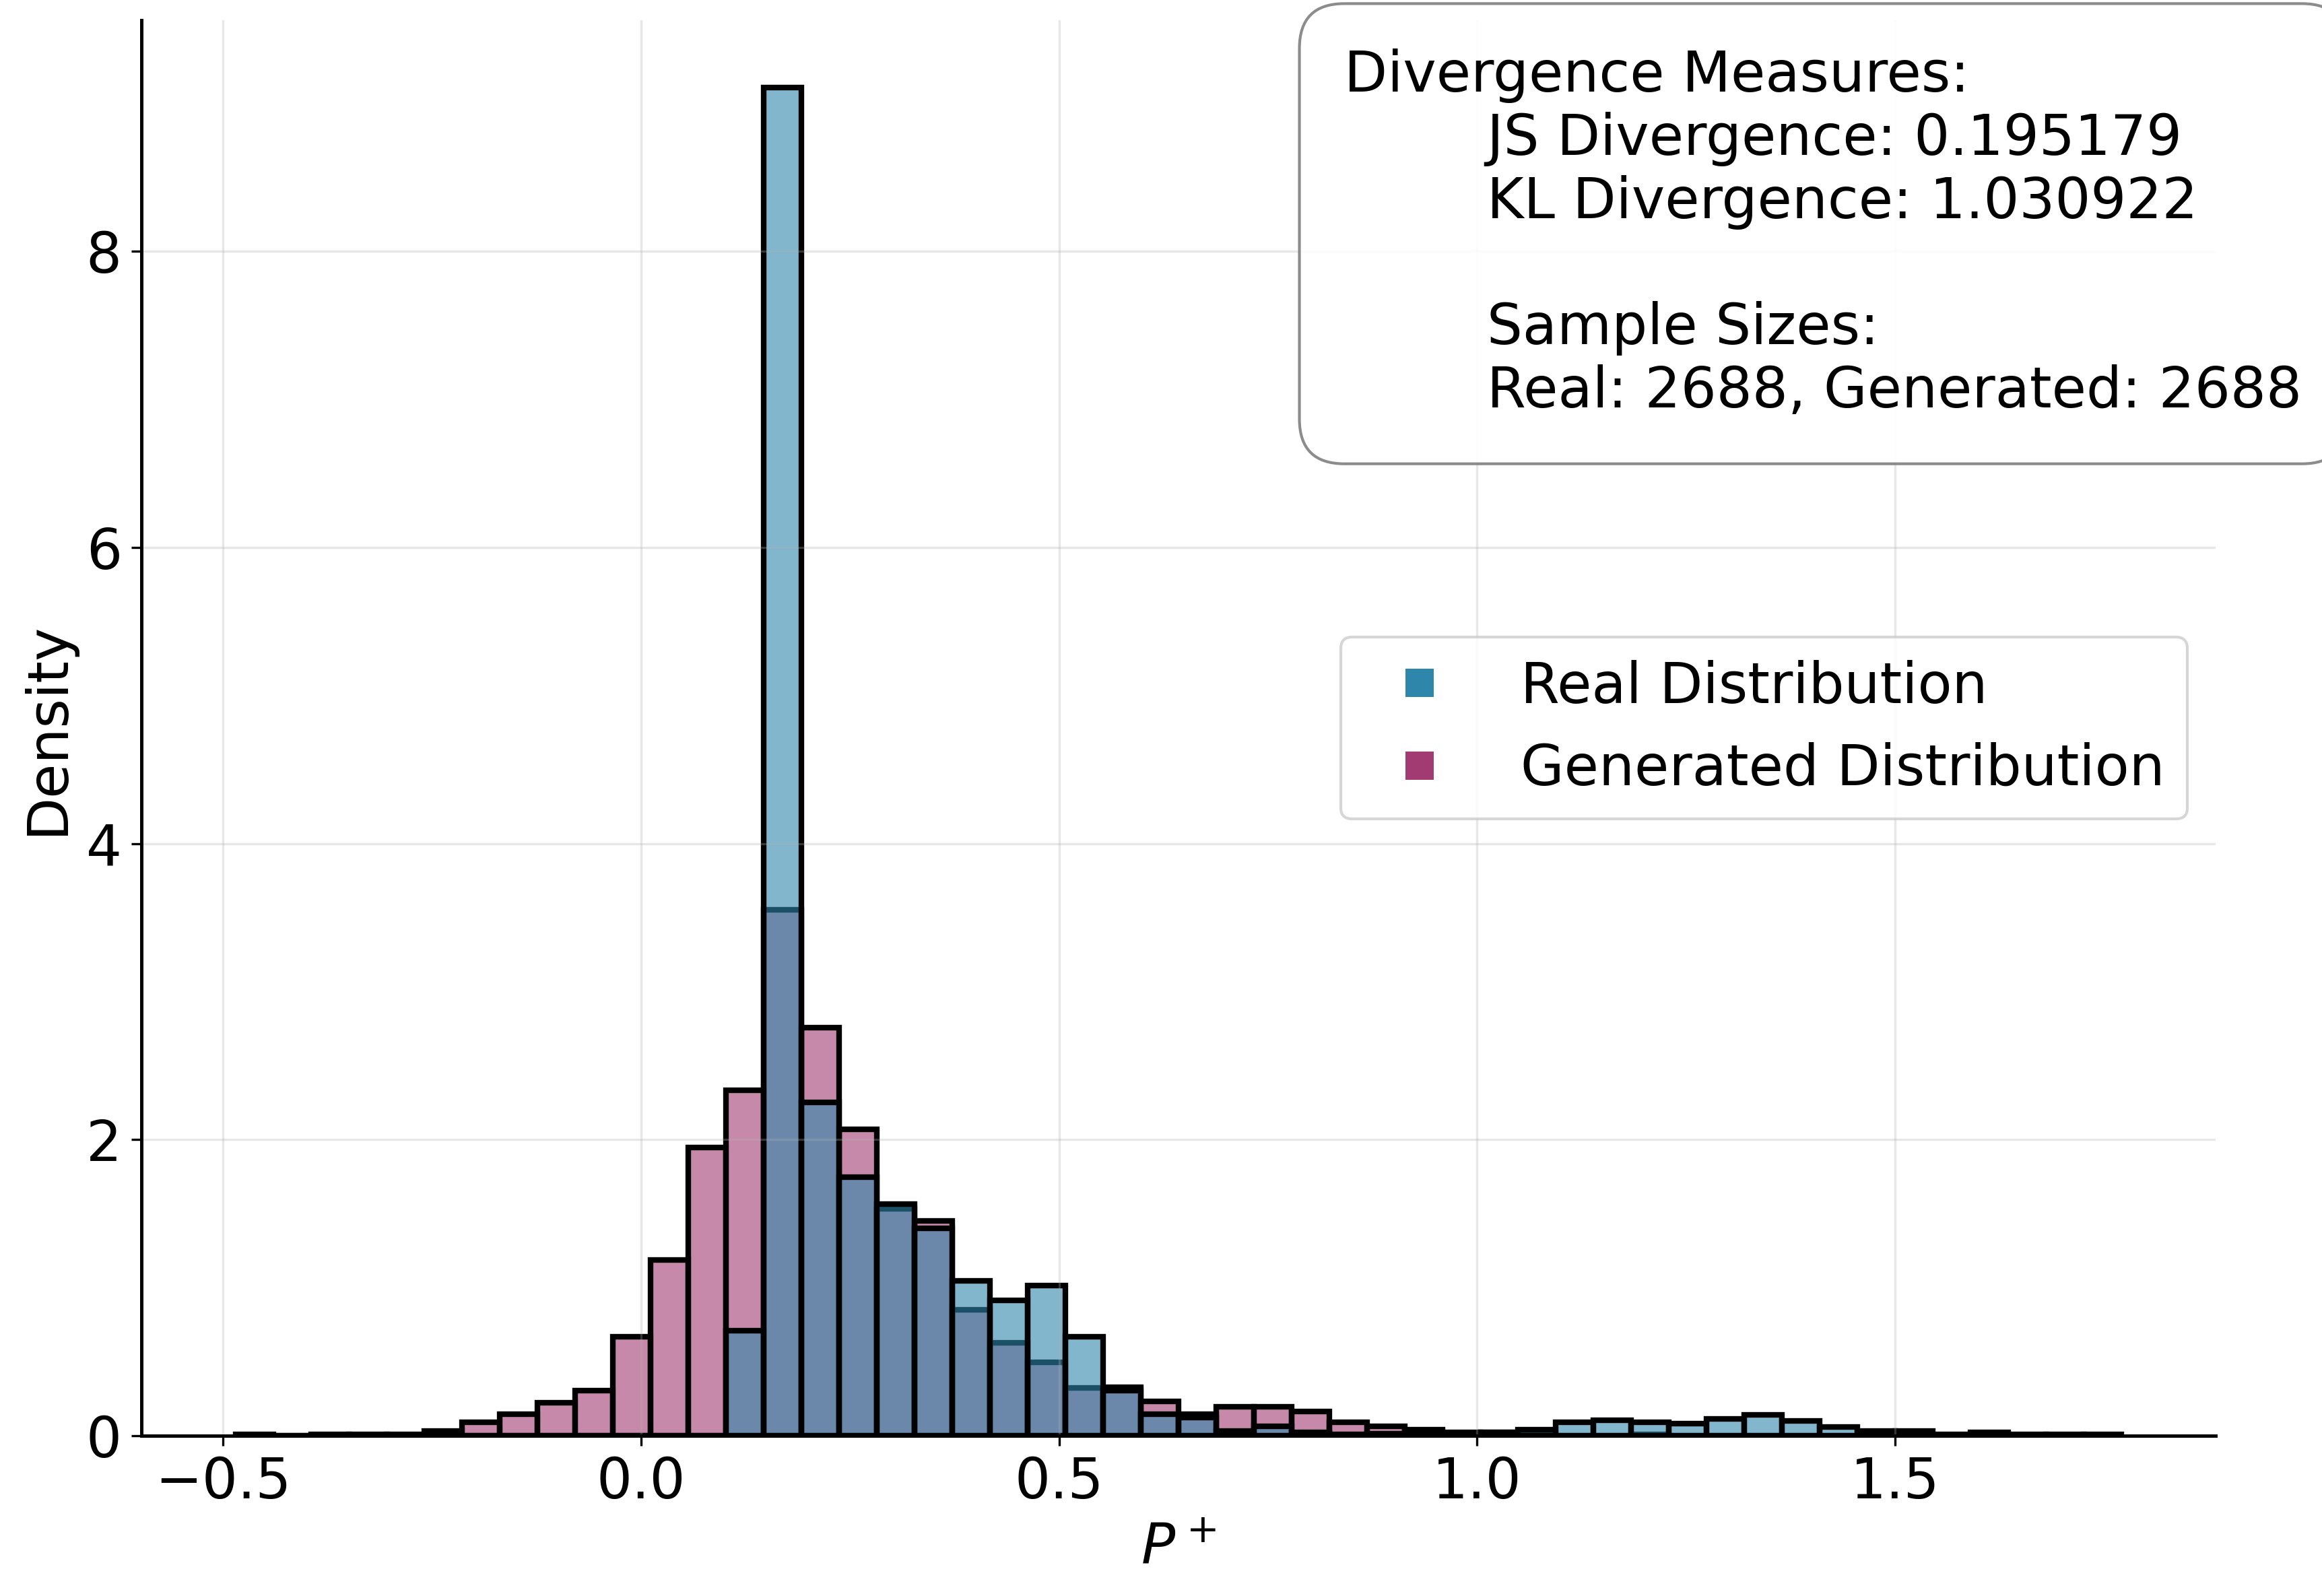

In [ ]:
generate_markdown_report_GAN(yaml_config=yaml_config, 
                             train_g_losses=all_losses['train_g_losses'], 
                             train_d_losses=all_losses['train_d_losses'], 
                             train_d_accuracies=all_losses['train_d_accuracies'], 
                             parent_dir=parent_dir, 
                             test_loader_G=test_loader_G, 
                             model_G=model_G, 
                             sampled_input_data_G=sampled_input_data_G) 